# Relatório da Análise Exploratória de Dados

**Universidade Estadual de Montes Claros**  
**Especialização em Ciência de Dados**  
**Disciplina:** Projeto Integrado em Ciência de Dados  
**Docente:** Dra. Luciana Balieiro Cosme  
**Alunos:**
*  Luan Silva Gomes
*  Mateus Nobre Silva Almeida
*  Paulo Matheus Mendes  

**Projeto:** Predizer o desempenho em Língua Portuguesa e Matemática, do 5º e 9º ano do Ensino Fundamental, das escolas Estaduais e Municipais do estado de Minas Gerais, utilizando a série histórica de 2015-2025 disponível no Portal das Avaliações Educacionais de Minas Gerais, para que Instituições e pessoas interessadas possam tomar medidas e criar políticas com maior eficiência a fim de melhorar esses indicadores.

## Importação de Dependências e Configurações Básicas

In [1]:
from pathlib import Path
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

In [2]:
cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif len(cwd.parents) >= 2 and (cwd.parents[1] / "src").exists():
    PROJECT_ROOT = cwd.parents[1]
else:
    PROJECT_ROOT = cwd

sys.path.insert(0, str(PROJECT_ROOT))

from src.simave_preprocessing import (
    find_descriptor_files,
    filter_etapas,
    filter_valid_target,
    load_descriptor_files,
    make_binary_target,
    summarize_target_status,
)

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"

print(f"Projeto: {PROJECT_ROOT}")
print(f"Diretório esperado dos dados brutos: {DATA_RAW_DIR}")

Projeto: /Users/luangomes/Code/projeto-integrado-simave-mg
Diretório esperado dos dados brutos: /Users/luangomes/Code/projeto-integrado-simave-mg/data/raw


## 1. Importação e contexto dos dados

- **Fonte:** Portal das Avaliações Educacionais de Minas Gerais (SIMAVE)
- **Link:** Arquivos das Redes Estadual e Municipal presentes na seção Descritores no Portal das Avaliações do Estado de MG [https://avaliacoes.educacao.mg.gov.br/dados-abertos](https://avaliacoes.educacao.mg.gov.br/dados-abertos)
- **Data de acesso:** 05/06/2026
- **Período avaliado:** 2015 a 2025

**Procedimento de obtenção dos dados:**
- Ao acessar a página supracitada, os dados foram baixados utilizando os links de cada ano das Redes Estadual e Municipal presentes na seção Descritores
- Cada link direcionava para uma planilha `.xlsx` no Planilhas (Google Drive) e cada planilha foi transformada no formato `.csv` utilizando a função Arquivo > Baixar > Valores separados por vírgula (.csv) disponível na aplicação Planilhas do Google
- Após o download, os arquivos `.csv` foram renomeados para seguir o padrão `DESCRITORES-<ANO>-ESCOLA-REDE-<MUNICIPAL|ESTADUAL>.csv`
- O notebook espera os CSVs brutos em `data/raw/`, com o padrão `DESCRITORES-<ANO>-ESCOLA-REDE-<MUNICIPAL|ESTADUAL>.csv`.

**Observações sobre disponibilidade dos dados:**
- Ainda que disponíveis na página, não foi possível acessar o link das seguintes planilhas da Rede Estadual referentes aos anos de 2017 e 2018 e do ano de 2017 da Rede Municipal
- Além disso, os anos de 2020 e 2025 não possuem dados disponíveis na página

**Observações sobre características dos arquivos de dados:**
- As planilhas exportadas do portal têm três linhas introdutórias antes do cabeçalho real. A função de carga já pula essas linhas, padroniza nomes de colunas e remove linhas de rodapé como fonte/observação.



In [19]:
files = find_descriptor_files(DATA_RAW_DIR)

if not files:
    raise FileNotFoundError(
        "Nenhum CSV encontrado. Coloque os arquivos em data/raw/ ou ajuste SAMPLE_CSV."
    )

df_raw = load_descriptor_files(files)
print(f"Arquivos carregados: {len(files)}")
print(f"Linhas e colunas após limpeza básica: {df_raw.shape}")
display(pd.DataFrame({"arquivo": [str(file) for file in files[:20]]}))
display(df_raw.head())

Arquivos carregados: 14
Linhas e colunas após limpeza básica: (5569725, 25)


,arquivo
0,/Users/luangomes/Code/projeto-integrado-simave...
1,/Users/luangomes/Code/projeto-integrado-simave...
2,/Users/luangomes/Code/projeto-integrado-simave...
3,/Users/luangomes/Code/projeto-integrado-simave...
4,/Users/luangomes/Code/projeto-integrado-simave...
5,/Users/luangomes/Code/projeto-integrado-simave...
6,/Users/luangomes/Code/projeto-integrado-simave...
7,/Users/luangomes/Code/projeto-integrado-simave...
8,/Users/luangomes/Code/projeto-integrado-simave...
9,/Users/luangomes/Code/projeto-integrado-simave...


,tipo,codigo_regional,regional,codigo_municipio,municipio,codigo_escola,escola,edicao,rede,codigo_etapa,...,tipo_norm,rede_norm,etapa_norm,disciplina_norm,regional_norm,municipio_norm,is_matematica,is_estadual,acerto_original,acerto_status
0,ESCOLA,1,METROPOLITANA A,3105400,BARAO DE COCAIS,31007692,EE JOSE MARIA DE MORAIS,2015,ESTADUAL,7,...,ESCOLA,ESTADUAL,7O ANO EF,LINGUA PORTUGUESA,METROPOLITANA A,BARAO DE COCAIS,0,1,65,ok
1,ESCOLA,1,METROPOLITANA A,3105400,BARAO DE COCAIS,31007692,EE JOSE MARIA DE MORAIS,2015,ESTADUAL,7,...,ESCOLA,ESTADUAL,7O ANO EF,LINGUA PORTUGUESA,METROPOLITANA A,BARAO DE COCAIS,0,1,70,ok
2,ESCOLA,1,METROPOLITANA A,3105400,BARAO DE COCAIS,31007692,EE JOSE MARIA DE MORAIS,2015,ESTADUAL,7,...,ESCOLA,ESTADUAL,7O ANO EF,LINGUA PORTUGUESA,METROPOLITANA A,BARAO DE COCAIS,0,1,61,ok
3,ESCOLA,1,METROPOLITANA A,3105400,BARAO DE COCAIS,31007692,EE JOSE MARIA DE MORAIS,2015,ESTADUAL,7,...,ESCOLA,ESTADUAL,7O ANO EF,LINGUA PORTUGUESA,METROPOLITANA A,BARAO DE COCAIS,0,1,64,ok
4,ESCOLA,1,METROPOLITANA A,3105400,BARAO DE COCAIS,31007692,EE JOSE MARIA DE MORAIS,2015,ESTADUAL,7,...,ESCOLA,ESTADUAL,7O ANO EF,LINGUA PORTUGUESA,METROPOLITANA A,BARAO DE COCAIS,0,1,46,ok


In [20]:
print("Colunas disponíveis:")
display(pd.DataFrame({"coluna": df_raw.columns, "tipo": [str(dtype) for dtype in df_raw.dtypes]}))

duplicadas = int(df_raw.duplicated().sum())
print(f"Registros duplicados: {duplicadas:,}")

anos_disponiveis = sorted(df_raw["edicao"].dropna().unique()) if "edicao" in df_raw.columns else []
print(f"Anos disponíveis nos arquivos carregados: {anos_disponiveis}")

Colunas disponíveis:


,coluna,tipo
0,tipo,string
1,codigo_regional,Int64
2,regional,string
3,codigo_municipio,Int64
4,municipio,string
5,codigo_escola,Int64
6,escola,str
7,edicao,Int64
8,rede,string
9,codigo_etapa,Int64


Registros duplicados: 0
Anos disponíveis nos arquivos carregados: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. Filtragem de dados: 5º e 9º ano

O problema do grupo está restrito ao 5º e 9º ano do Ensino Fundamental. A filtragem é feita pelo `codigo_etapa`, porque o texto da etapa pode variar um pouco entre arquivos.

In [21]:
df_59 = filter_etapas(df_raw, etapas=(5, 9))

print(f"Registros totais carregados: {len(df_raw):,}")
print(f"Registros no escopo do projeto (5º e 9º ano dp Ensino Fundamental): {len(df_59):,}")
print(f"Proporção mantida: {len(df_59) / len(df_raw):.2%}")

display(
    df_59.groupby(["edicao", "rede", "etapa", "disciplina"], dropna=False)
    .size()
    .rename("registros")
    .reset_index()
    .sort_values(["edicao", "rede", "etapa", "disciplina"])
    .head(30)
)

Registros totais carregados: 5,569,725
Registros no escopo do projeto (5º e 9º ano dp Ensino Fundamental): 2,350,470
Proporção mantida: 42.20%


,edicao,rede,etapa,disciplina,registros
0,2016,ESTADUAL,5º ANO EF,LINGUA PORTUGUESA,31136
1,2016,ESTADUAL,5º ANO EF,MATEMATICA,50596
2,2016,ESTADUAL,9º ANO EF,LINGUA PORTUGUESA,63595
3,2016,ESTADUAL,9º ANO EF,MATEMATICA,113365
4,2016,MUNICIPAL,5º ANO EF,LINGUA PORTUGUESA,83232
5,2016,MUNICIPAL,5º ANO EF,MATEMATICA,135252
6,2016,MUNICIPAL,9º ANO EF,LINGUA PORTUGUESA,34615
7,2016,MUNICIPAL,9º ANO EF,MATEMATICA,61705
8,2019,ESTADUAL,5º ANO EF,LINGUA PORTUGUESA,29257
9,2019,ESTADUAL,5º ANO EF,MATEMATICA,47565


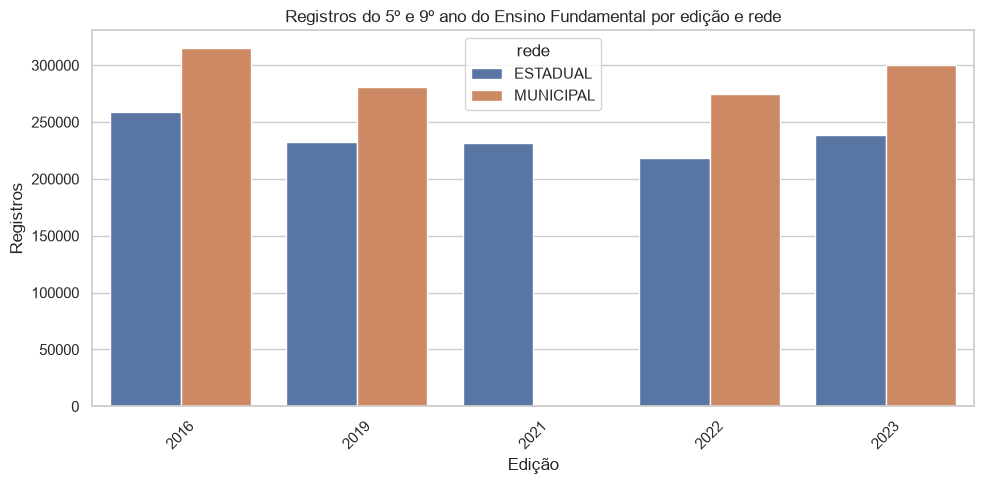

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ordem_anos = sorted(df_59["edicao"].dropna().unique())
sns.countplot(data=df_59, x="edicao", hue="rede", order=ordem_anos, ax=ax)
ax.set_title("Registros do 5º e 9º ano do Ensino Fundamental por edição e rede")
ax.set_xlabel("Edição")
ax.set_ylabel("Registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Qualidade da variável alvo

Nos dados brutos, a variável alvo original é `% acerto`. Ele foi convertido para a coluna numérica `acerto`.

Valores `BP` e `-` não são notas. Por isso, eles não devem ser imputados com média, mediana ou moda. Na modelagem principal, esses registros precisam ser removidos ou tratados em uma análise separada.

In [24]:
status_alvo = summarize_target_status(df_59)

print("Status do alvo por grupo:")
display(status_alvo.head(30))

resumo_status = (
    df_59["acerto_status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="registros")
)
resumo_status["percentual"] = (resumo_status["registros"] / resumo_status["registros"].sum() * 100).round(2)
display(resumo_status)

Status do alvo por grupo:


,edicao,rede,etapa,disciplina,acerto_status,registros,percentual
0,2016,ESTADUAL,5º ANO EF,LINGUA PORTUGUESA,baixa_participacao,32,0.10
1,2016,ESTADUAL,5º ANO EF,LINGUA PORTUGUESA,ok,31085,99.84
2,2016,ESTADUAL,5º ANO EF,LINGUA PORTUGUESA,vazio,19,0.06
3,2016,ESTADUAL,5º ANO EF,MATEMATICA,baixa_participacao,52,0.10
4,2016,ESTADUAL,5º ANO EF,MATEMATICA,ok,50463,99.74
5,2016,ESTADUAL,5º ANO EF,MATEMATICA,vazio,81,0.16
6,2016,ESTADUAL,9º ANO EF,LINGUA PORTUGUESA,baixa_participacao,575,0.90
7,2016,ESTADUAL,9º ANO EF,LINGUA PORTUGUESA,ok,63020,99.10
8,2016,ESTADUAL,9º ANO EF,MATEMATICA,baixa_participacao,1025,0.90
9,2016,ESTADUAL,9º ANO EF,MATEMATICA,ok,112311,99.07


,status,registros,percentual
0,ok,2033790,86.53
1,baixa_participacao,293108,12.47
2,sem_valor,19663,0.84
3,vazio,3909,0.17


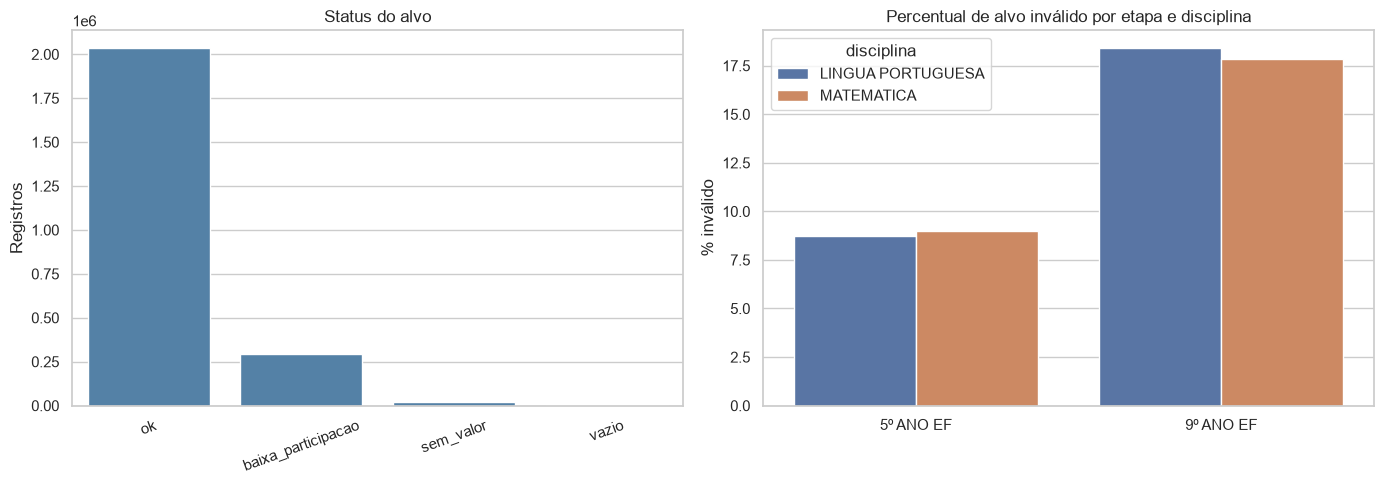

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=resumo_status, x="status", y="registros", color="steelblue", ax=axes[0])
axes[0].set_title("Status do alvo")
axes[0].set_xlabel("")
axes[0].set_ylabel("Registros")
axes[0].tick_params(axis="x", rotation=20)

status_por_grupo = (
    df_59.assign(invalido=df_59["acerto_status"].ne("ok"))
    .groupby(["etapa", "disciplina"], dropna=False)["invalido"]
    .mean()
    .mul(100)
    .reset_index(name="percentual_invalido")
)
sns.barplot(
    data=status_por_grupo,
    x="etapa",
    y="percentual_invalido",
    hue="disciplina",
    ax=axes[1],
)
axes[1].set_title("Percentual de alvo inválido por etapa e disciplina")
axes[1].set_xlabel("")
axes[1].set_ylabel("% inválido")
plt.tight_layout()
plt.show()

In [26]:
df_valid = filter_valid_target(df_59, target="acerto")
removidos = len(df_59) - len(df_valid)

print(f"Registros no escopo: {len(df_59):,}")
print(f"Registros com acerto numérico válido: {len(df_valid):,}")
print(f"Registros sem alvo válido removidos da análise do alvo: {removidos:,} ({removidos / len(df_59):.2%})")

display(df_valid["acerto"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2).to_frame())

Registros no escopo: 2,350,470
Registros com acerto numérico válido: 2,033,790
Registros sem alvo válido removidos da análise do alvo: 316,680 (13.47%)


,acerto
count,2033790.0
mean,54.31
std,21.71
min,0.0
1%,0.0
5%,19.0
25%,40.0
50%,55.0
75%,69.0
95%,91.0


## 4. Distribuição do desempenho

A variável `acerto` é contínua, de 0 a 100.

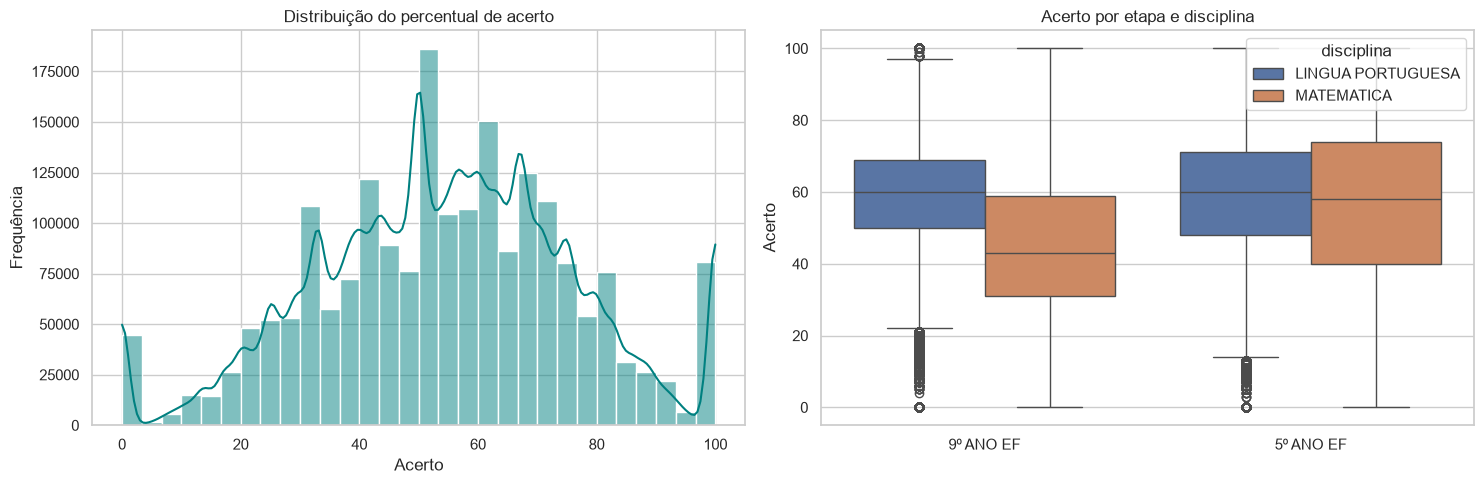

Assimetria do alvo: -0.112


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df_valid, x="acerto", bins=30, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Distribuição do percentual de acerto")
axes[0].set_xlabel("Acerto")
axes[0].set_ylabel("Frequência")

sns.boxplot(data=df_valid, x="etapa", y="acerto", hue="disciplina", ax=axes[1])
axes[1].set_title("Acerto por etapa e disciplina")
axes[1].set_xlabel("")
axes[1].set_ylabel("Acerto")

plt.tight_layout()
plt.show()

assimetria = df_valid["acerto"].skew()
print(f"Assimetria do alvo: {assimetria:.3f}")

In [28]:
resumo_desempenho = (
    df_valid.groupby(["etapa", "disciplina"], dropna=False)
    .agg(
        registros=("acerto", "size"),
        media=("acerto", "mean"),
        mediana=("acerto", "median"),
        desvio_padrao=("acerto", "std"),
        minimo=("acerto", "min"),
        maximo=("acerto", "max"),
    )
    .round(2)
    .reset_index()
)

display(resumo_desempenho)

,etapa,disciplina,registros,media,mediana,desvio_padrao,minimo,maximo
0,5º ANO EF,LINGUA PORTUGUESA,405140,58.78,60.0,19.14,0.0,100.0
1,5º ANO EF,MATEMATICA,664163,56.84,58.0,24.4,0.0,100.0
2,9º ANO EF,LINGUA PORTUGUESA,365510,59.3,60.0,15.12,0.0,100.0
3,9º ANO EF,MATEMATICA,598977,45.42,43.0,20.92,0.0,100.0


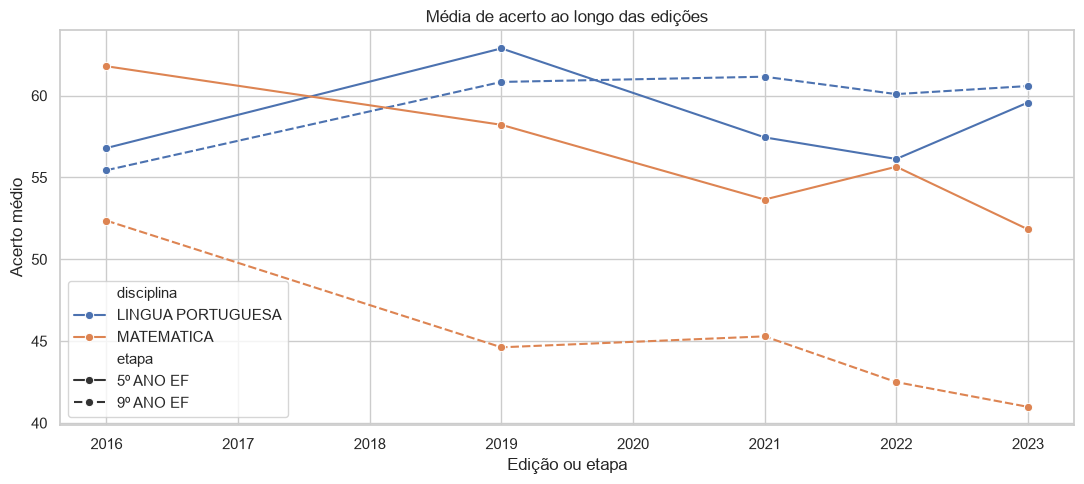

In [29]:
fig, ax = plt.subplots(figsize=(11, 5))

if df_valid["edicao"].nunique() > 1:
    serie = (
        df_valid.groupby(["edicao", "etapa", "disciplina"], dropna=False)["acerto"]
        .mean()
        .reset_index()
    )
    sns.lineplot(data=serie, x="edicao", y="acerto", hue="disciplina", style="etapa", marker="o", ax=ax)
    ax.set_title("Média de acerto ao longo das edições")
else:
    serie = (
        df_valid.groupby(["etapa", "disciplina"], dropna=False)["acerto"]
        .mean()
        .reset_index()
    )
    sns.barplot(data=serie, x="etapa", y="acerto", hue="disciplina", ax=ax)
    ax.set_title("Média de acerto por etapa e disciplina")

ax.set_xlabel("Edição ou etapa")
ax.set_ylabel("Acerto médio")
plt.tight_layout()
plt.show()

## 5. Baixo desempenho como diagnóstico exploratório

Criamos uma variável diagnóstica simples: `baixo_desempenho_50`, quando `acerto < 50`. Ela não substitui a variável alvo, serve apenas para entender a proporção de registros abaixo de um limiar fácil de explicar.

,etapa,disciplina,registros,proporcao_baixo_desempenho,acerto_medio
0,5º ANO EF,LINGUA PORTUGUESA,405140,0.263,58.777
1,5º ANO EF,MATEMATICA,664163,0.347,56.839
2,9º ANO EF,LINGUA PORTUGUESA,365510,0.236,59.302
3,9º ANO EF,MATEMATICA,598977,0.607,45.421


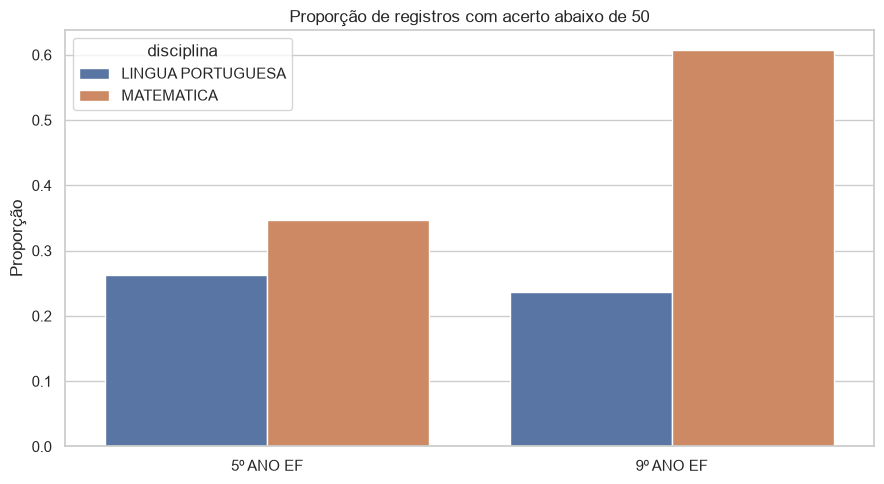

In [30]:
df_diag = make_binary_target(
    df_valid,
    threshold=50,
    target="acerto",
    output="baixo_desempenho_50",
)

baixo_por_grupo = (
    df_diag.groupby(["etapa", "disciplina"], dropna=False)
    .agg(
        registros=("baixo_desempenho_50", "size"),
        proporcao_baixo_desempenho=("baixo_desempenho_50", "mean"),
        acerto_medio=("acerto", "mean"),
    )
    .round(3)
    .reset_index()
)
display(baixo_por_grupo)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=baixo_por_grupo,
    x="etapa",
    y="proporcao_baixo_desempenho",
    hue="disciplina",
    ax=ax,
)
ax.set_title("Proporção de registros com acerto abaixo de 50")
ax.set_xlabel("")
ax.set_ylabel("Proporção")
plt.tight_layout()
plt.show()

## 6. Relações com variáveis categóricas

A base tem muitas variáveis categóricas: rede, etapa, disciplina, regional, município, escola e descritor. Por isso, a correlação linear entre códigos numéricos e `acerto` deve ser lida com cautela. O código da escola, por exemplo, é um identificador, não uma medida ordenada.

In [31]:
for coluna in ["rede", "regional", "municipio", "descritor_nome"]:
    if coluna not in df_valid.columns:
        continue
    resumo = (
        df_valid.groupby(coluna, dropna=False)
        .agg(registros=("acerto", "size"), acerto_medio=("acerto", "mean"))
        .reset_index()
    )
    resumo = resumo.loc[resumo["registros"] >= 30].sort_values("acerto_medio")
    print(f"\nMenores médias por {coluna}:")
    display(resumo.head(10).round(2))
    print(f"Maiores médias por {coluna}:")
    display(resumo.tail(10).round(2))


Menores médias por rede:


,rede,registros,acerto_medio
0,ESTADUAL,1004965,53.13
1,MUNICIPAL,1028825,55.45


Maiores médias por rede:


,rede,registros,acerto_medio
0,ESTADUAL,1004965,53.13
1,MUNICIPAL,1028825,55.45



Menores médias por regional:


...

,municipio,registros,acerto_medio
294,FORTALEZA DE MINAS,456,65.97
644,RIO ESPERA,1113,66.16
224,CRISTAIS,1412,66.32
240,DESTERRO DO MELO,429,66.43
752,SAO PEDRO DA UNIAO,641,66.68
256,DOM VICOSO,811,67.18
129,CANAA,1132,67.55
647,RIO PARANAIBA,1612,67.92
608,POCRANE,2690,68.18
482,MERCES,759,73.03



Menores médias por descritor_nome:


,descritor_nome,registros,acerto_medio
143,HMT097,1336,19.32
66,D64,14538,24.35
142,HMT096,1336,25.6
63,D61,14533,27.2
141,HMT095,1337,27.5
39,D32_SAEB,3530,27.59
140,HMT094,1337,28.68
34,D27_SAEB,3524,28.79
64,D62,14530,29.43
65,D63,14537,30.31


Maiores médias por descritor_nome:


,descritor_nome,registros,acerto_medio
145,HMT099,1336,76.06
80,HLP024,2635,76.35
72,D85,14541,76.43
104,HMT057,1287,77.86
69,D83,23826,77.88
30,D25_5EF,3930,79.96
55,D47_5EF,3943,82.18
70,D83_5EF,3942,82.74
130,HMT084,1337,85.19
97,HMT042,1290,85.4


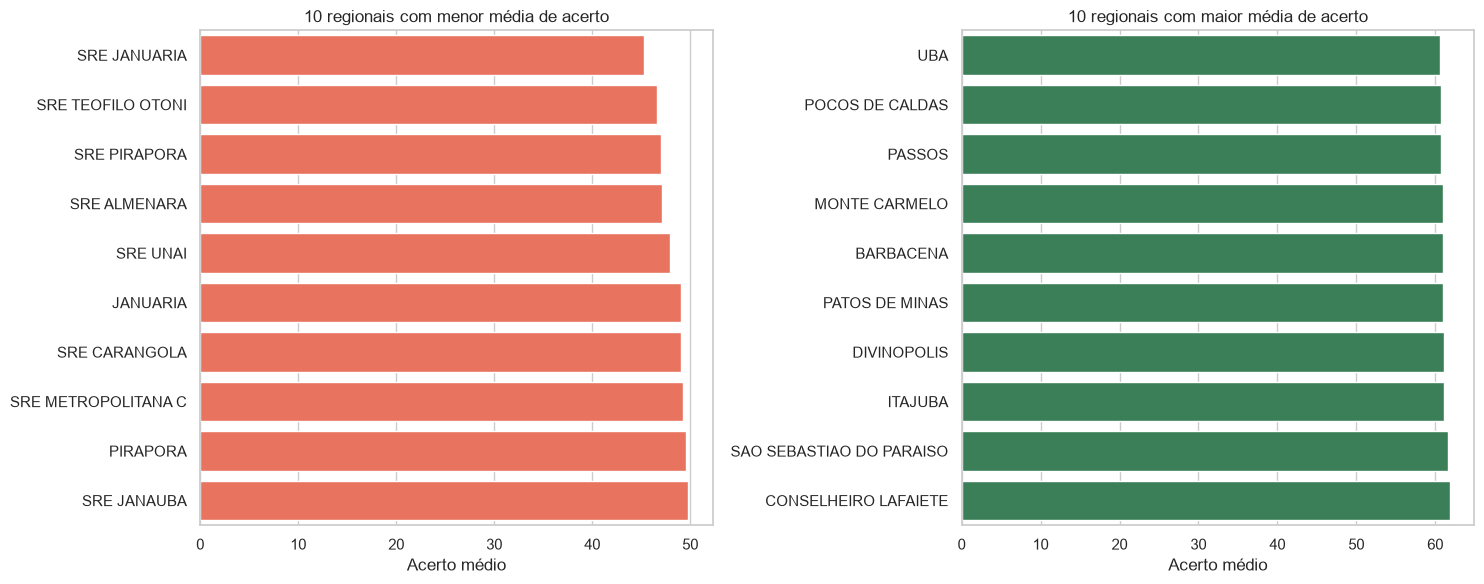

In [32]:
if "regional" in df_valid.columns:
    regional = (
        df_valid.groupby("regional", dropna=False)
        .agg(registros=("acerto", "size"), acerto_medio=("acerto", "mean"))
        .reset_index()
    )
    regional = regional.loc[regional["registros"] >= 30].sort_values("acerto_medio")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.barplot(data=regional.head(10), x="acerto_medio", y="regional", color="tomato", ax=axes[0])
    axes[0].set_title("10 regionais com menor média de acerto")
    axes[0].set_xlabel("Acerto médio")
    axes[0].set_ylabel("")

    sns.barplot(data=regional.tail(10), x="acerto_medio", y="regional", color="seagreen", ax=axes[1])
    axes[1].set_title("10 regionais com maior média de acerto")
    axes[1].set_xlabel("Acerto médio")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

## 7. Matriz de correlação

A matriz abaixo é útil como diagnóstico, mas não deve ser usada como única evidência de que há ou não há sinal nos dados. Isso porque colunas como `codigo_escola` e `codigo_municipio` não têm distância numérica interpretável, são identificadores. Além disso, relações importantes podem aparecer em interações categóricas, como `etapa + disciplina + descritor`.

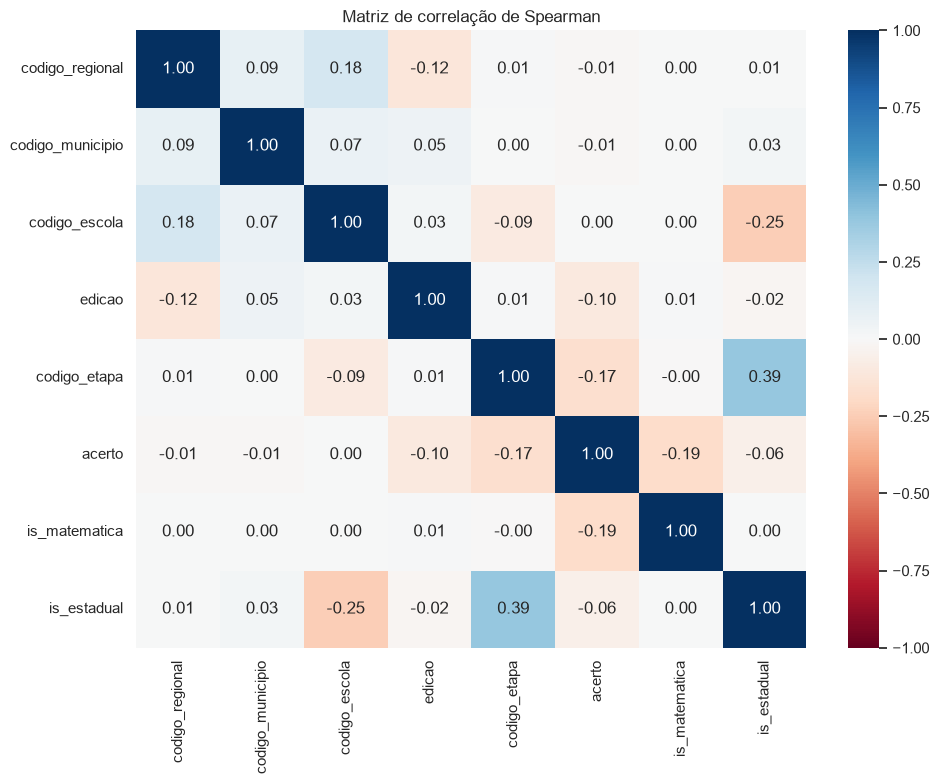

Correlação com acerto:


,spearman
codigo_escola,0.001
codigo_regional,-0.010
codigo_municipio,-0.014
is_estadual,-0.059
edicao,-0.100
codigo_etapa,-0.168
is_matematica,-0.186


In [33]:
cols_corr = [
    "codigo_regional",
    "codigo_municipio",
    "codigo_escola",
    "edicao",
    "codigo_etapa",
    "acerto",
    "is_matematica",
    "is_estadual",
]
cols_corr = [coluna for coluna in cols_corr if coluna in df_valid.columns]
df_corr = df_valid[cols_corr].copy()

for coluna in df_corr.columns:
    df_corr[coluna] = pd.to_numeric(df_corr[coluna], errors="coerce")

matriz = df_corr.corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, cmap="RdBu", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlação de Spearman")
plt.tight_layout()
plt.show()

print("Correlação com acerto:")
display(matriz["acerto"].drop("acerto").sort_values(ascending=False).round(3).to_frame("spearman"))

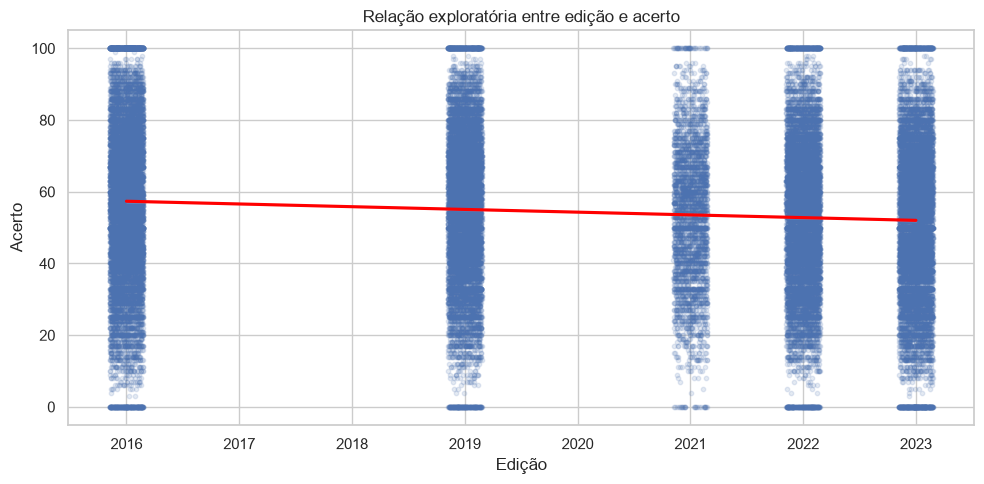

In [34]:
sample_size = min(50000, len(df_valid))
df_sample = df_valid.sample(sample_size, random_state=RANDOM_STATE) if len(df_valid) > sample_size else df_valid

fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(
    data=df_sample,
    x="edicao",
    y="acerto",
    scatter_kws={"alpha": 0.15, "s": 10},
    line_kws={"color": "red"},
    x_jitter=0.15,
    ax=ax,
)
ax.set_title("Relação exploratória entre edição e acerto")
ax.set_xlabel("Edição")
ax.set_ylabel("Acerto")
plt.tight_layout()
plt.show()